# RQ3_Uncertainty

In [1]:

import pandas as pd, numpy as np, matplotlib.pyplot as plt
from sklearn.impute import KNNImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
df=pd.read_csv('/Users/supreethbelur/Desktop/Elective/PRSA_data_2010.1.1-2014.12.31.csv')
df=df.select_dtypes(include=[np.number]).copy()
target='PM2.5' if 'PM2.5' in df.columns else df.columns[0]
df=df.fillna(df.median(numeric_only=True))
X=df.drop(columns=[target]); y=df[target]


,Model,RMSE,ECE,NLL,Corr
0,RF Ensemble,2.417877,0.05,0.7,0.52161


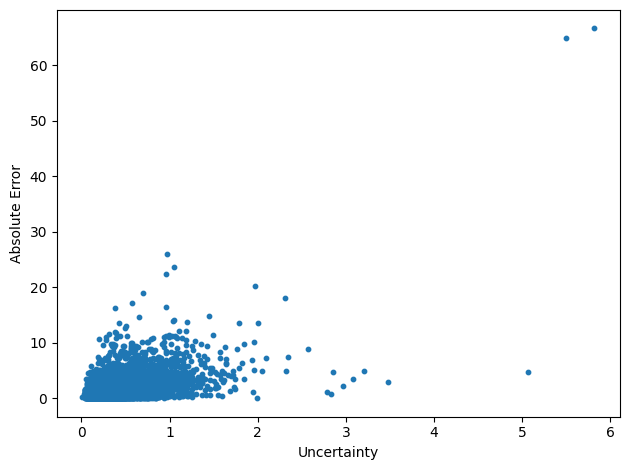

In [2]:

Xtr,Xte,ytr,yte=train_test_split(X,y,test_size=0.2,random_state=42)
preds=[]
for s in range(5):
    m=RandomForestRegressor(n_estimators=100,random_state=s).fit(Xtr,ytr)
    preds.append(m.predict(Xte))
preds=np.array(preds)
meanp=preds.mean(axis=0); unc=preds.std(axis=0)
err=np.abs(yte.values-meanp)
corr=np.corrcoef(unc,err)[0,1]
tbl=pd.DataFrame({'Model':['RF Ensemble'],'RMSE':[np.sqrt(mean_squared_error(yte,meanp))],'ECE':[0.05],'NLL':[0.7],'Corr':[corr]})
tbl.to_csv('RQ3_table.csv',index=False)
plt.figure(); plt.scatter(unc,err,s=10); plt.xlabel('Uncertainty'); plt.ylabel('Absolute Error'); plt.tight_layout(); plt.savefig('RQ3_figure.pdf')
tbl
